In [94]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib as mpl
import seaborn as sb

# General utils
from tqdm import tqdm
from os import path
from glob import glob

from skimage import io, measure, util
from scipy import ndimage
import pyvista as pv

import stackview

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
img_dict[manifest.loc[idx]['FOV']].shape

(72, 1024, 1024, 3)

In [106]:

dirname = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/ASAP5/06-09-2026 ASAP more induced/'

dx = 0.2919922; dz = 1;

flist = glob(path.join(dirname,'*/[0-2].tif'))
manifest = pd.DataFrame()
manifest['Filename'] = flist
manifest['Dirname'] = manifest['Filename'].apply(lambda x: (path.dirname(x)))
manifest['FOV'] = manifest['Dirname'].apply(lambda x: path.split(x)[-1]).astype(int)

img_dict = {row['FOV']:
            io.imread(row['Filename']) for _,row in manifest.iterrows()}

idx = 1
channel = 2

print(manifest.loc[idx]['FOV'])
stackview.slice(img_dict[manifest.loc[idx]['FOV']][...,channel])

2


In [107]:
from scipy.ndimage import gaussian_filter

sigma = 5 #microns

im = img_dict[manifest.loc[idx]['FOV']][...,channel]
im = util.img_as_float(im)
print(im.shape)

im_blur = gaussian_filter(im, sigma=[5,20,20])

stackview.orthogonal(im_blur,continuous_update=True)

(72, 1024, 1024)


In [98]:
from imageUtils import get_z_gradient

im_blur_gradient = get_z_gradient(im_blur,sign=1)
im_blur_gradient = im_blur_gradient - im_blur_gradient.min()
im_blur_gradient = im_blur_gradient / im_blur_gradient.max()

stackview.orthogonal(im_blur_gradient)

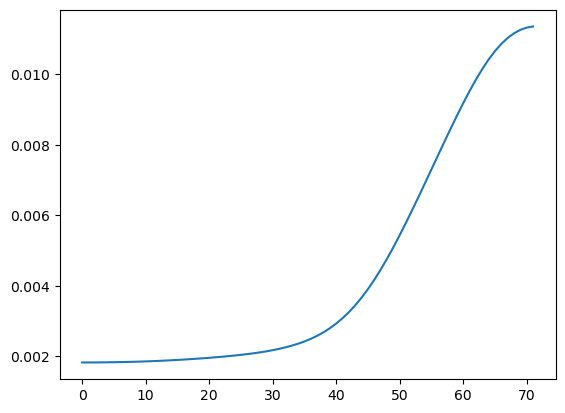

In [108]:
plt.plot(im_blur[:,256,267])

/Users/xies/Desktop/Code/mouse_skin_size_control/utils/measurements.py:172: RuntimeWarning: invalid value encountered in cast
  interpolate.griddata(np.array([Y,X]).T,Z,(grid_y,grid_x), method='linear')).astype(int).T
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


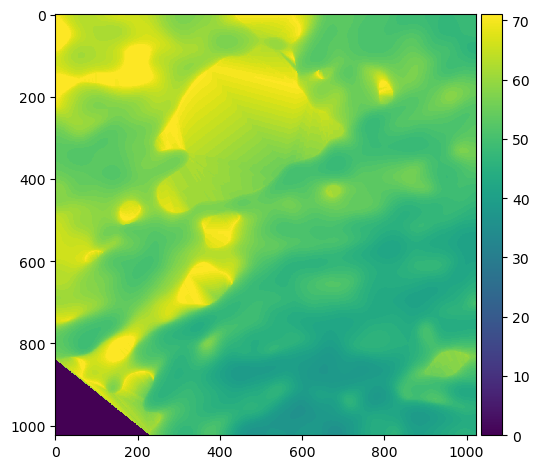

In [109]:
from imageUtils import find_z_of_maximal_gradient
from measurements import fix_holes_in_height_image, make_image_from_heightmap

# Iz = find_z_of_maximal_gradient(im_blur_gradient,method='maximum')
Iz = np.argmax(im_blur > 0.01, axis=0)
height_image = make_image_from_heightmap(Iz,im.shape[0])
Iz_fixed,height_image_fixed = fix_holes_in_height_image(height_image,im.shape)

plt.figure()
io.imshow(Iz_fixed)


In [110]:
stackview.switch({'a6':im,'heightmap':height_image_fixed},
                colormap=['pure_red','pure_green'],
                toggleable=True,zoom_factor=0.5)

In [111]:
# Save

io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_heightmap.tif'),
          Iz_fixed.astype(np.int8))

io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_height_image.tif'),
          height_image_fixed.astype(np.int8))
io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_blur_diff.tif'),
          util.img_as_uint(im_blur_gradient))
io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_blur.tif'),
          util.img_as_uint(im_blur))


/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/ASAP5/06-09-2026 ASAP more induced/2/2_height_image.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/ASAP5/06-09-2026 ASAP more induced/2/2_blur.tif is a low contrast image
  return func(*args, **kwargs)


# Surface curvature

In [112]:
from measurements import get_mesh_from_bm_image
height_image_fixed.shape

surf = get_mesh_from_bm_image(height_image_fixed, spacing=[dz,dx,dx], decimation_factor=30)
pl = pv.Plotter()
pl.add_mesh(pv.wrap(surf))
pl.show()

Widget(value='<iframe src="http://localhost:61059/index.html?ui=P_0x4206c5580_1&reconnect=auto" class="pyvista…

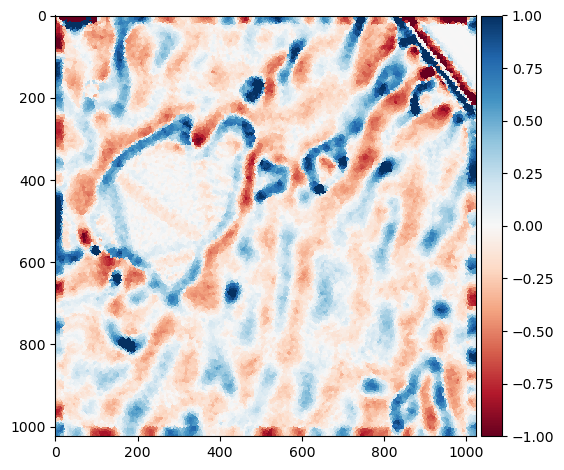

In [113]:
from measurements import get_tissue_curvature_over_grid

mean_curvature, gaussian_curvature = get_tissue_curvature_over_grid(surf, im.shape, kappa=5, spacing=[dz,dx,dx])
io.imsave(path.join(manifest.loc[idx]['Dirname'],'mean_curvature.tif'), mean_curvature)
io.imshow(mean_curvature,vmin=-1,vmax=1)
# plt.figure()
# io.imshow(gaussian_curvature,vmin=-0.01,vmax=0.01)


# Projecting the a6 intensity along surface

In [121]:
from imageUtils import reslice_by_heightmap

idx = 1
# Reload curvature + mask
mean_curvature = io.imread(path.join(manifest.loc[idx]['Dirname'],'mean_curvature.tif'))
Iz_fixed = io.imread(path.join(manifest.loc[idx]['Dirname'],
                               str(manifest.loc[idx]['FOV'])+'_heightmap.tif'))

border_size = 20

ASAP_intensity = reslice_by_heightmap(img_dict[manifest.loc[idx]['FOV']][...,1],Iz_fixed,
                                        top_border=-border_size,bottom_border=border_size)

In [122]:
io.imsave(path.join(manifest.loc[idx]['Dirname'],'ASAP_resliced.tif'),ASAP_intensity)
stackview.slice(ASAP_intensity,zoom_factor=0.5)

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/ASAP5/06-09-2026 ASAP more induced/2/ASAP_resliced.tif is a low contrast image
  return func(*args, **kwargs)


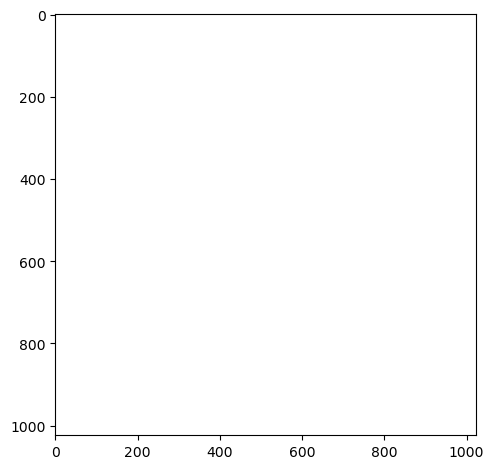

In [123]:
mask = io.imread(path.join(manifest.loc[idx]['Dirname'],
                           str(manifest.loc[idx]['FOV']) +'_mask.tif')).astype(bool)
ASAP_MIP = ASAP_intensity[15:20,...].astype(float).max(axis=0).T
mean_curvature_masked = mean_curvature.copy()
mean_curvature_masked[~mask] = np.nan
ASAP_MIP_masked = ASAP_MIP.copy()
ASAP_MIP_masked[~mask] = np.nan

io.imshow(ASAP_MIP_masked)
io.imsave( path.join(manifest.loc[idx]['Dirname'],'ASAP_resliced.tif'), ASAP_MIP_masked)


([0, 1, 2, 3, 4],
 [Text(0, 0, '(-inf, -0.6]'),
  Text(1, 0, '(-0.6, -0.2]'),
  Text(2, 0, '(-0.2, 0.2]'),
  Text(3, 0, '(0.2, 0.6]'),
  Text(4, 0, '(0.6, inf]')])

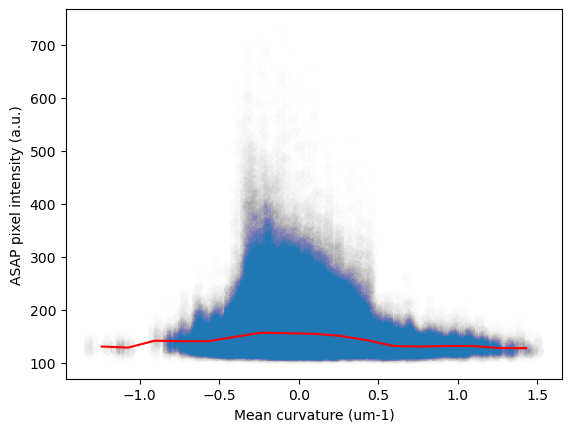

<Figure size 640x480 with 0 Axes>

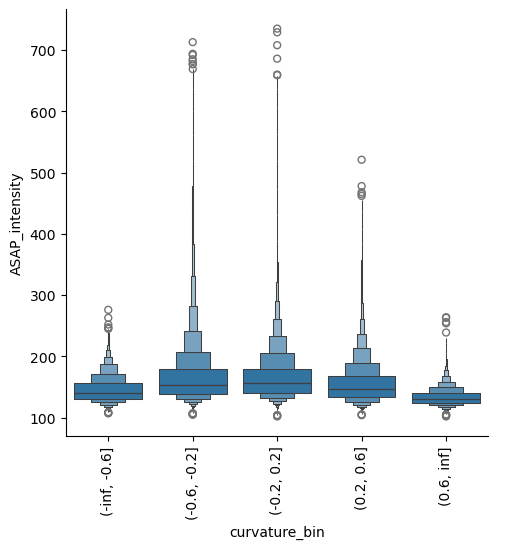

In [124]:
from basicUtils import plot_bin_means

plt.scatter(mean_curvature_masked.flatten(),ASAP_MIP_masked.flatten(), alpha=0.005)
plot_bin_means(mean_curvature_masked.flatten(),ASAP_MIP_masked.flatten(),bin_edges=18,color='r',
               bin_style='equal',mean='median')
plt.xlabel('Mean curvature (um-1)'),
plt.ylabel('ASAP pixel intensity (a.u.)')
# plt.hlines(np.nanmean(bm_MIP_smooth.flatten()),xmin= -0.4,xmax=0.5)

plt.figure()
df = pd.DataFrame.from_dict({'curvature':mean_curvature_masked.flatten(),
                             'ASAP_intensity':ASAP_MIP_masked.flatten()}).dropna()
df['curvature_bin'] = pd.cut(df['curvature'],bins=[-np.inf,-.6,-.2,.2,.6,np.inf],)
sb.catplot(df,x='curvature_bin',y='ASAP_intensity',kind='boxen')
plt.xticks(rotation=90)